# Notebook 9 - Battery Sentinel : tri-noise router

Ce notebook transforme les écarts du predictive twin en décisions.

C'est ici que la logique du projet devient un vrai système : chaque cas est routé vers un régime d'incertitude, puis vers une action simple.


## Lien avec la première partie

Les trois familles de bruit de la partie diffusion sont réutilisées ici comme trois régimes d'interprétation :
- variation normale ;
- télémétrie bornée ou quantifiée ;
- anomalie impulsive.

Le router sert à séparer ces trois cas.


In [9]:
!pip install -q torch torchvision matplotlib pandas numpy seaborn scikit-learn


In [10]:
import json
import os
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn

IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
    if not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive')
except Exception:
    drive = None

FOUNDATION_DRIVE_DIR = '/content/drive/MyDrive/diffusion_noise_project'
FOUNDATION_DIR = '/content/foundation_diffusion_noise_project'
BATTERY_ROOT = '/content/drive/MyDrive/battery_sentinel'

if IN_COLAB:
    if not os.path.exists(FOUNDATION_DIR):
        if not os.path.exists(FOUNDATION_DRIVE_DIR):
            raise FileNotFoundError(f'Foundation artifacts not found in Drive: {FOUNDATION_DRIVE_DIR}')
        shutil.copytree(FOUNDATION_DRIVE_DIR, FOUNDATION_DIR)
else:
    FOUNDATION_DIR = str((Path.cwd() / 'diffusion_noise_project' / 'diffusion_noise_project').resolve())
    BATTERY_ROOT = str((Path.cwd() / 'diffusion_noise_project' / 'diffusion_noise_project' / 'battery_sentinel').resolve())

DATA_DIR = os.path.join(BATTERY_ROOT, 'data')
LOG_DIR = os.path.join(BATTERY_ROOT, 'logs')
FIGURE_DIR = os.path.join(BATTERY_ROOT, 'figures')
MODEL_DIR = os.path.join(BATTERY_ROOT, 'models')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Foundation root:', FOUNDATION_DIR)
print('Battery Sentinel root:', BATTERY_ROOT)
print('Device:', DEVICE)



Foundation root: /content/foundation_diffusion_noise_project
Battery Sentinel root: /content/drive/MyDrive/battery_sentinel
Device: cuda


In [11]:
TRAIN_CONFIG = json.load(open(os.path.join(LOG_DIR, 'twin_training_summary.json'), 'r', encoding='utf-8'))['train_config']
ROUTER_CONFIG = {
    'seed': 42,
    'window': TRAIN_CONFIG['window'],
    'stride': 2,
    'selection_holdout': 0.20,
    'nominal_threshold_quantile': 0.95,
    'label_order': ['gaussian', 'uniform', 'laplace'],
}

TARGET_FEATURE_NAMES = ['soc', 'voltage', 'temperature']
WINDOW_FEATURE_NAMES = ['soc', 'voltage', 'current', 'temperature']
QUANT_STEPS = np.array([0.01, 0.025, 1.0, 0.5], dtype=np.float32)
TARGET_QUANT_STEPS = np.array([0.01, 0.025, 0.5], dtype=np.float32)

def load_dataset():
    payload = np.load(os.path.join(DATA_DIR, 'battery_sentinel_dataset.npz'), allow_pickle=True)
    return {
        'true_series': payload['true_series'].astype(np.float32),
        'observed_series': payload['observed_series'].astype(np.float32),
        'regime_labels': payload['regime_labels'],
        'val_indices': payload['val_indices'],
        'test_indices': payload['test_indices'],
    }

def build_windows(dataset, indices, window, stride):
    inputs, true_targets, observed_targets, regimes, session_ids, window_starts = [], [], [], [], [], []
    target_idx = [0, 1, 3]
    for session_id in indices:
        observed = dataset['observed_series'][session_id]
        true = dataset['true_series'][session_id]
        regime = str(dataset['regime_labels'][session_id])
        for start in range(0, observed.shape[0] - window - 1, stride):
            end = start + window
            inputs.append(observed[start:end])
            true_targets.append(true[end, target_idx])
            observed_targets.append(observed[end, target_idx])
            regimes.append(regime)
            session_ids.append(int(session_id))
            window_starts.append(int(start))
    return (
        np.stack(inputs).astype(np.float32),
        np.stack(true_targets).astype(np.float32),
        np.stack(observed_targets).astype(np.float32),
        np.array(regimes),
        np.array(session_ids),
        np.array(window_starts),
    )

class BatteryTwinGRU(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, num_layers: int, dropout: float):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers=num_layers, dropout=dropout if num_layers > 1 else 0.0, batch_first=True)
        self.head = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.SiLU(), nn.Linear(hidden_dim, 3))

    def forward(self, x):
        output, _ = self.gru(x)
        return self.head(output[:, -1])

def gaussian_nll(residuals, sigma):
    return 0.5 * np.sum(np.log(2 * np.pi * sigma**2) + (residuals / sigma) ** 2, axis=1)

def uniform_score(residuals, half_width):
    overflow = np.maximum(np.abs(residuals) - half_width, 0.0)
    return np.sum(np.log(2 * half_width) + 30.0 * overflow, axis=1)

def laplace_nll(residuals, scale):
    return np.sum(np.log(2 * scale) + np.abs(residuals) / scale, axis=1)

def build_router_features(x_windows, pred_targets, observed_targets):
    residual = observed_targets - pred_targets
    abs_res = np.abs(residual)
    sq_res = residual ** 2
    diffs = np.diff(x_windows, axis=1)
    abs_diffs = np.abs(diffs)

    feature_blocks = []
    feature_names = []

    def add_block(block, names):
        feature_blocks.append(block.astype(np.float32))
        feature_names.extend(names)

    add_block(residual, [f'residual_{name}' for name in TARGET_FEATURE_NAMES])
    add_block(abs_res, [f'abs_residual_{name}' for name in TARGET_FEATURE_NAMES])
    add_block(sq_res, [f'sq_residual_{name}' for name in TARGET_FEATURE_NAMES])
    add_block(abs_res.mean(axis=1, keepdims=True), ['residual_abs_mean'])
    add_block(abs_res.max(axis=1, keepdims=True), ['residual_abs_max'])
    add_block(np.linalg.norm(residual, axis=1, keepdims=True), ['residual_l2'])

    add_block(x_windows[:, -1, :], [f'last_{name}' for name in WINDOW_FEATURE_NAMES])
    add_block(x_windows[:, -1, :] - x_windows[:, -2, :], [f'last_delta_{name}' for name in WINDOW_FEATURE_NAMES])
    add_block(abs_diffs.mean(axis=1), [f'mean_abs_diff_{name}' for name in WINDOW_FEATURE_NAMES])
    add_block(abs_diffs.max(axis=1), [f'max_abs_diff_{name}' for name in WINDOW_FEATURE_NAMES])
    add_block(abs_diffs.std(axis=1), [f'std_abs_diff_{name}' for name in WINDOW_FEATURE_NAMES])

    grid = QUANT_STEPS.reshape(1, 1, -1)
    grid_dist = np.abs(x_windows - np.round(x_windows / grid) * grid)
    add_block(grid_dist.mean(axis=1), [f'mean_grid_dist_{name}' for name in WINDOW_FEATURE_NAMES])
    add_block((grid_dist < (grid * 0.05)).mean(axis=1), [f'grid_hit_ratio_{name}' for name in WINDOW_FEATURE_NAMES])
    add_block((abs_diffs < (grid[:, :, :] * 0.05)).mean(axis=1), [f'flat_ratio_{name}' for name in WINDOW_FEATURE_NAMES])

    target_grid = TARGET_QUANT_STEPS.reshape(1, -1)
    target_grid_dist = np.abs(observed_targets - np.round(observed_targets / target_grid) * target_grid)
    add_block(target_grid_dist, [f'target_grid_dist_{name}' for name in TARGET_FEATURE_NAMES])

    features = np.concatenate(feature_blocks, axis=1).astype(np.float32)
    return features, residual, feature_names

def build_candidate_models(seed: int):
    return {
        'logistic_regression': Pipeline([
            ('scaler', StandardScaler()),
            ('logreg', LogisticRegression(max_iter=1500, class_weight='balanced', C=1.2, random_state=seed)),
        ]),
        'random_forest': RandomForestClassifier(
            n_estimators=320,
            max_depth=16,
            min_samples_leaf=4,
            class_weight='balanced',
            random_state=seed,
            n_jobs=-1,
        ),
        'extra_trees': ExtraTreesClassifier(
            n_estimators=420,
            max_depth=None,
            min_samples_leaf=2,
            class_weight='balanced',
            random_state=seed,
            n_jobs=-1,
        ),
        'hist_gradient_boosting': HistGradientBoostingClassifier(
            max_depth=10,
            learning_rate=0.06,
            max_iter=260,
            random_state=seed,
        ),
    }

def extract_feature_importance(model, feature_names, top_k=12):
    values = None
    if hasattr(model, 'feature_importances_'):
        values = model.feature_importances_
    elif hasattr(model, 'named_steps') and 'logreg' in model.named_steps:
        values = np.mean(np.abs(model.named_steps['logreg'].coef_), axis=0)
    if values is None:
        return []
    order = np.argsort(values)[::-1][:top_k]
    return [
        {'feature': feature_names[idx], 'importance': float(values[idx])}
        for idx in order
    ]



In [12]:
dataset = load_dataset()
window = ROUTER_CONFIG['window']
stride = ROUTER_CONFIG['stride']

x_val, y_val_true, y_val_obs, regimes_val, sessions_val, starts_val = build_windows(dataset, dataset['val_indices'], window, stride)
x_test, y_test_true, y_test_obs, regimes_test, sessions_test, starts_test = build_windows(dataset, dataset['test_indices'], window, stride)

scalers = np.load(os.path.join(MODEL_DIR, 'battery_twin_scalers.npz'))
x_mean, x_std = scalers['x_mean'], scalers['x_std']
y_mean, y_std = scalers['y_mean'], scalers['y_std']
x_val_n = (x_val - x_mean) / x_std
x_test_n = (x_test - x_mean) / x_std

model = BatteryTwinGRU(input_dim=x_val_n.shape[-1], hidden_dim=TRAIN_CONFIG['hidden_dim'], num_layers=TRAIN_CONFIG['num_layers'], dropout=TRAIN_CONFIG['dropout']).to(DEVICE)
checkpoint = torch.load(os.path.join(MODEL_DIR, 'battery_twin_gru.pt'), map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.eval()

with torch.no_grad():
    pred_val = model(torch.from_numpy(x_val_n).to(DEVICE)).cpu().numpy() * y_std + y_mean
    pred_test = model(torch.from_numpy(x_test_n).to(DEVICE)).cpu().numpy() * y_std + y_mean

router_x_val, residual_val, feature_names = build_router_features(x_val, pred_val, y_val_obs)
router_x_test, residual_test, _ = build_router_features(x_test, pred_test, y_test_obs)

router_audit = {
    'val_windows': int(len(router_x_val)),
    'test_windows': int(len(router_x_test)),
    'num_features': int(router_x_val.shape[1]),
    'val_regime_counts': pd.Series(regimes_val).value_counts().to_dict(),
    'test_regime_counts': pd.Series(regimes_test).value_counts().to_dict(),
}
router_audit



{'val_windows': 11284,
 'test_windows': 11232,
 'num_features': 47,
 'val_regime_counts': {'laplace': 4264, 'uniform': 3692, 'gaussian': 3328},
 'test_regime_counts': {'gaussian': 3952, 'uniform': 3640, 'laplace': 3640}}

In [13]:
splitter = StratifiedShuffleSplit(n_splits=1, test_size=ROUTER_CONFIG['selection_holdout'], random_state=ROUTER_CONFIG['seed'])
router_train_idx, router_holdout_idx = next(splitter.split(router_x_val, regimes_val))

candidate_models = build_candidate_models(ROUTER_CONFIG['seed'])
selection_rows = []
for model_name, candidate in candidate_models.items():
    candidate.fit(router_x_val[router_train_idx], regimes_val[router_train_idx])
    holdout_pred = candidate.predict(router_x_val[router_holdout_idx])
    selection_rows.append({
        'model': model_name,
        'macro_f1': float(f1_score(regimes_val[router_holdout_idx], holdout_pred, labels=ROUTER_CONFIG['label_order'], average='macro')),
        'accuracy': float((holdout_pred == regimes_val[router_holdout_idx]).mean()),
    })

selection_df = pd.DataFrame(selection_rows).sort_values(['macro_f1', 'accuracy'], ascending=False).reset_index(drop=True)
best_model_name = selection_df.loc[0, 'model']
router_model = build_candidate_models(ROUTER_CONFIG['seed'])[best_model_name]
router_model.fit(router_x_val, regimes_val)

pred_labels = router_model.predict(router_x_test)
pred_proba = router_model.predict_proba(router_x_test)
pred_confidence = pred_proba.max(axis=1)

# Likelihood-only tri-noise baseline kept for comparison with the stronger supervised router.
gauss_val = residual_val[regimes_val == 'gaussian']
uniform_val = residual_val[regimes_val == 'uniform']
laplace_val = residual_val[regimes_val == 'laplace']

sigma = gauss_val.std(axis=0) + 1e-6
half_width = np.quantile(np.abs(uniform_val), 0.92, axis=0) + 1e-6
laplace_scale = np.mean(np.abs(laplace_val), axis=0) + 1e-6

likelihood_scores = {
    'gaussian': gaussian_nll(residual_test, sigma),
    'uniform': uniform_score(residual_test, half_width),
    'laplace': laplace_nll(residual_test, laplace_scale),
}
likelihood_score_matrix = np.stack([likelihood_scores['gaussian'], likelihood_scores['uniform'], likelihood_scores['laplace']], axis=1)
likelihood_pred_indices = likelihood_score_matrix.argmin(axis=1)
likelihood_pred_labels = np.array([ROUTER_CONFIG['label_order'][idx] for idx in likelihood_pred_indices])
likelihood_macro_f1 = float(f1_score(regimes_test, likelihood_pred_labels, labels=ROUTER_CONFIG['label_order'], average='macro'))

baseline_threshold = np.quantile(np.linalg.norm(gauss_val, axis=1), ROUTER_CONFIG['nominal_threshold_quantile'])
baseline_binary = np.where(np.linalg.norm(residual_test, axis=1) <= baseline_threshold, 'nominal', 'alert')
true_binary = np.where(regimes_test == 'gaussian', 'nominal', 'alert')



In [14]:
cm = confusion_matrix(regimes_test, pred_labels, labels=ROUTER_CONFIG['label_order'])
report = classification_report(regimes_test, pred_labels, labels=ROUTER_CONFIG['label_order'], output_dict=True)
macro_f1 = float(f1_score(regimes_test, pred_labels, labels=ROUTER_CONFIG['label_order'], average='macro'))
weighted_f1 = float(f1_score(regimes_test, pred_labels, labels=ROUTER_CONFIG['label_order'], average='weighted'))
accuracy = float((pred_labels == regimes_test).mean())
baseline_f1 = float(f1_score(true_binary, baseline_binary, average='binary', pos_label='alert'))

predicted_action = np.where(
    pred_labels == 'gaussian',
    'monitor_normal_operation',
    np.where(pred_labels == 'uniform', 'request_higher_resolution_telemetry', 'raise_inspection_alert')
)

eval_df = pd.DataFrame({
    'window_index': np.arange(len(pred_labels)),
    'session_id': sessions_test,
    'window_start': starts_test,
    'window_end': starts_test + window,
    'true_regime': regimes_test,
    'predicted_regime': pred_labels,
    'likelihood_predicted_regime': likelihood_pred_labels,
    'predicted_action': predicted_action,
    'model_confidence': pred_confidence,
    'joint_residual_norm': np.linalg.norm(residual_test, axis=1),
})
eval_df.to_csv(os.path.join(LOG_DIR, 'router_predictions.csv'), index=False)

top_features = extract_feature_importance(router_model, feature_names, top_k=12)
metrics_payload = {
    'router_config': ROUTER_CONFIG,
    'selected_model': best_model_name,
    'model_selection': selection_df.to_dict(orient='records'),
    'sigma': sigma.tolist(),
    'uniform_half_width': half_width.tolist(),
    'laplace_scale': laplace_scale.tolist(),
    'macro_f1': macro_f1,
    'weighted_f1': weighted_f1,
    'accuracy': accuracy,
    'likelihood_macro_f1': likelihood_macro_f1,
    'baseline_binary_f1': baseline_f1,
    'classification_report': report,
    'confusion_matrix': cm.tolist(),
    'label_order': ROUTER_CONFIG['label_order'],
    'action_counts': eval_df['predicted_action'].value_counts().to_dict(),
    'top_feature_importances': top_features,
}
with open(os.path.join(LOG_DIR, 'router_metrics.json'), 'w', encoding='utf-8') as handle:
    json.dump(metrics_payload, handle, indent=2)

display(selection_df)
pd.DataFrame(report).T[['precision', 'recall', 'f1-score', 'support']]



,model,macro_f1,accuracy
0,random_forest,0.999554,0.999557
1,extra_trees,0.999554,0.999557
2,hist_gradient_boosting,0.999109,0.999114
3,logistic_regression,0.997329,0.997342


,precision,recall,f1-score,support
gaussian,0.999493,0.997723,0.998607,3952.000000
uniform,1.000000,1.000000,1.000000,3640.000000
laplace,0.997532,0.999451,0.998490,3640.000000
accuracy,0.999021,0.999021,0.999021,0.999021
macro avg,0.999008,0.999058,0.999033,11232.000000
weighted avg,0.999022,0.999021,0.999021,11232.000000


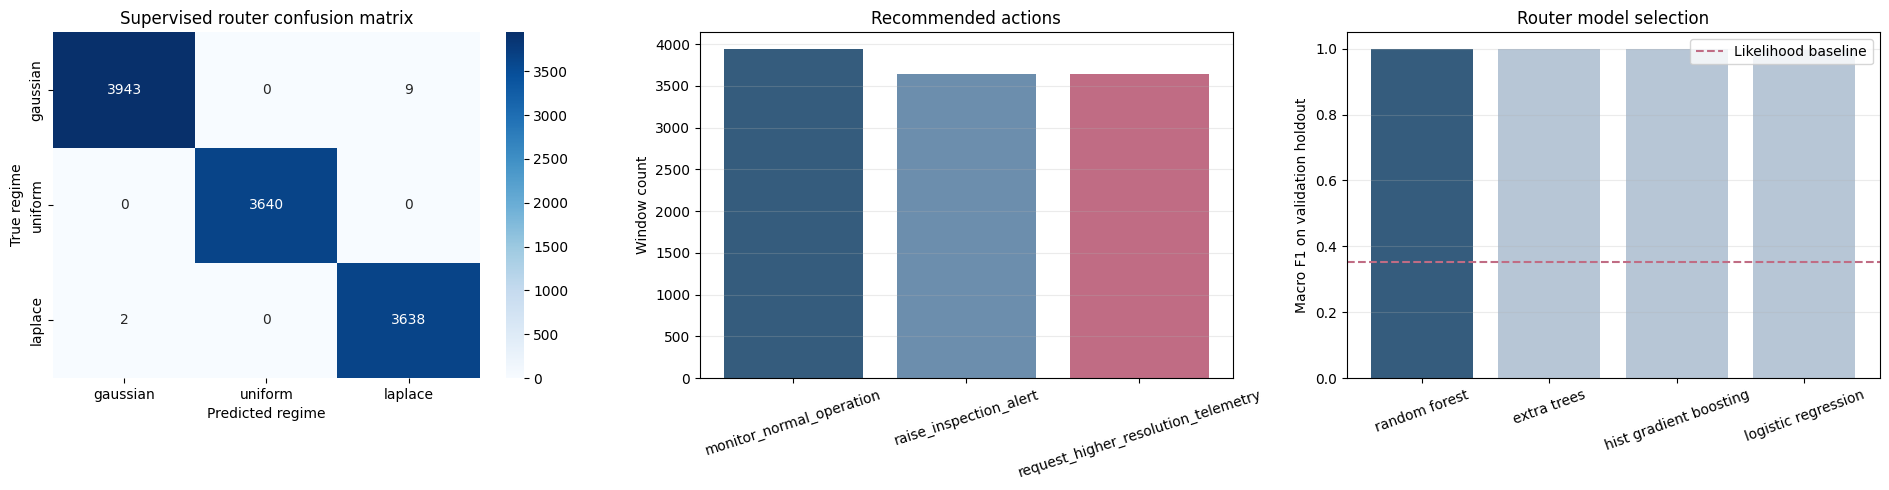

Saved: /content/drive/MyDrive/battery_sentinel/figures/battery_router_confusion.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ROUTER_CONFIG['label_order'], yticklabels=ROUTER_CONFIG['label_order'], ax=axes[0])
axes[0].set_title('Supervised router confusion matrix')
axes[0].set_xlabel('Predicted regime')
axes[0].set_ylabel('True regime')

action_counts = eval_df['predicted_action'].value_counts().sort_index()
axes[1].bar(action_counts.index, action_counts.values, color=['#355c7d', '#6c8ead', '#c06c84'])
axes[1].set_title('Recommended actions')
axes[1].set_ylabel('Window count')
axes[1].tick_params(axis='x', rotation=18)
axes[1].grid(axis='y', alpha=0.25)

plot_selection = selection_df.copy()
plot_selection['model'] = plot_selection['model'].str.replace('_', ' ')
axes[2].bar(plot_selection['model'], plot_selection['macro_f1'], color=['#355c7d' if name == best_model_name.replace('_', ' ') else '#b7c6d6' for name in plot_selection['model']])
axes[2].axhline(likelihood_macro_f1, color='#c06c84', linestyle='--', label='Likelihood baseline')
axes[2].set_title('Router model selection')
axes[2].set_ylabel('Macro F1 on validation holdout')
axes[2].tick_params(axis='x', rotation=20)
axes[2].legend(loc='best')
axes[2].grid(axis='y', alpha=0.25)

fig.tight_layout()
cm_path = os.path.join(FIGURE_DIR, 'battery_router_confusion.png')
fig.savefig(cm_path, dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', cm_path)



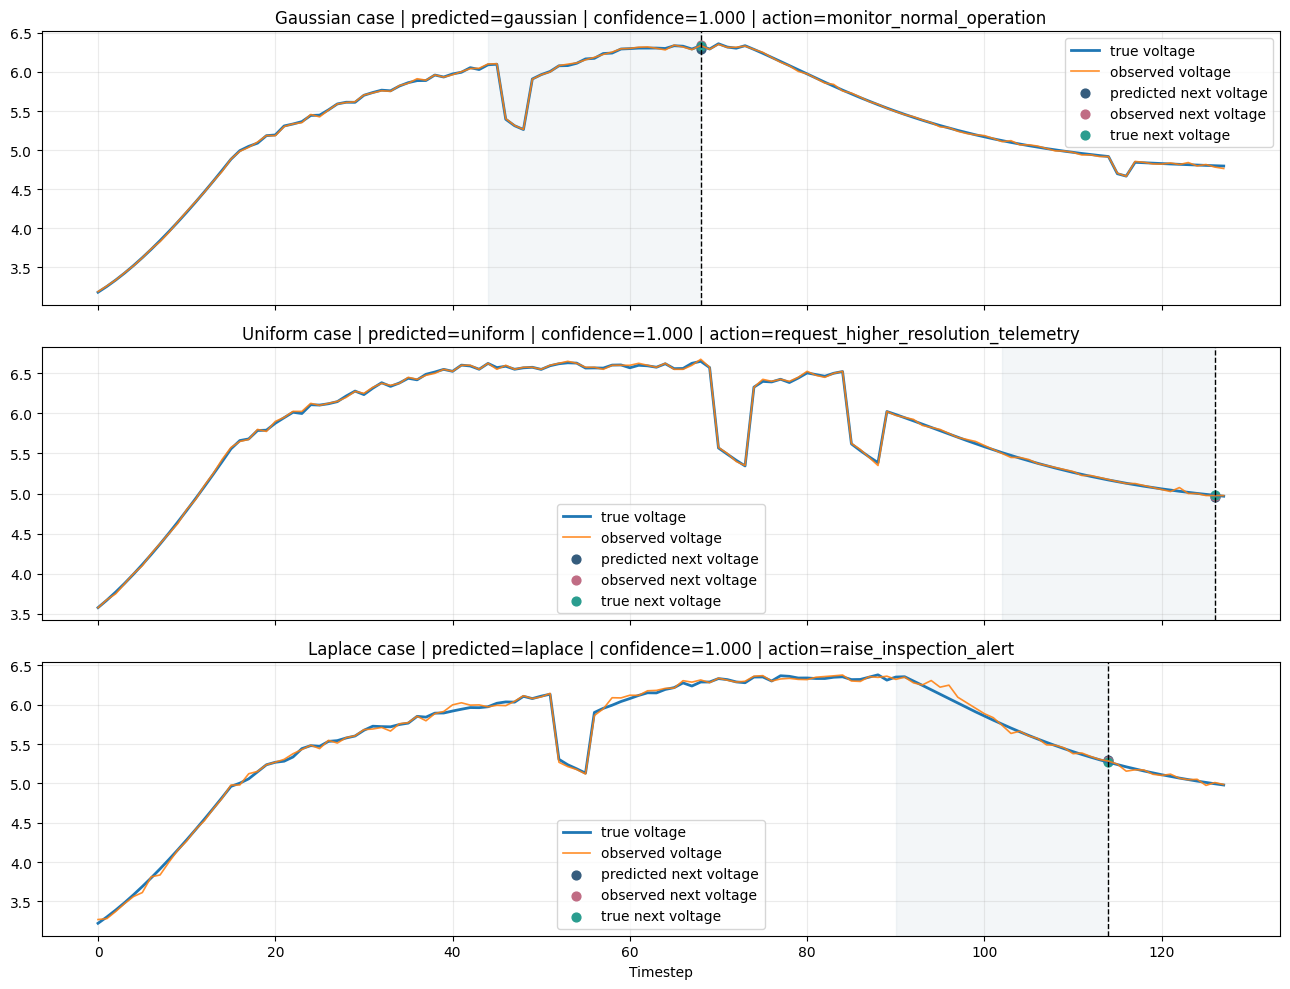

Saved: /content/drive/MyDrive/battery_sentinel/figures/battery_router_case_studies.png


In [17]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
for ax, regime in zip(axes, ROUTER_CONFIG['label_order']):
    subset = eval_df[eval_df['true_regime'] == regime].copy()
    correct_subset = subset[subset['predicted_regime'] == regime]
    chosen = correct_subset.sort_values('model_confidence', ascending=False).iloc[0] if len(correct_subset) > 0 else subset.sort_values('model_confidence', ascending=False).iloc[0]

    row_idx = int(chosen['window_index'])
    session_id = int(chosen['session_id'])
    window_start = int(chosen['window_start'])
    window_end = int(chosen['window_end'])
    observed = dataset['observed_series'][session_id]
    true = dataset['true_series'][session_id]

    ax.plot(true[:, 1], label='true voltage', linewidth=2)
    ax.plot(observed[:, 1], label='observed voltage', linewidth=1.2, alpha=0.88)
    ax.axvspan(window_start, window_end, alpha=0.08, color='#6c8ead')
    ax.axvline(window_end, color='black', linestyle='--', linewidth=1)
    ax.scatter([window_end], [pred_test[row_idx, 1]], color='#355c7d', s=40, label='predicted next voltage')
    ax.scatter([window_end], [y_test_obs[row_idx, 1]], color='#c06c84', s=40, label='observed next voltage')
    ax.scatter([window_end], [y_test_true[row_idx, 1]], color='#2a9d8f', s=40, label='true next voltage')
    ax.set_title(
        f"{regime.title()} case | predicted={chosen['predicted_regime']} | "
        f"confidence={chosen['model_confidence']:.3f} | action={chosen['predicted_action']}"
    )
    ax.grid(alpha=0.25)
    ax.legend(loc='best')

axes[-1].set_xlabel('Timestep')
fig.tight_layout()
case_path = os.path.join(FIGURE_DIR, 'battery_router_case_studies.png')
fig.savefig(case_path, dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', case_path)



## Résultats attendus

À la fin de ce notebook, on obtient :
- un tableau de prédictions ;
- une confusion matrix ;
- des exemples de cas interprétés ;
- un résumé chiffré du router final.
